## 1. Load and Import

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PROC  = Path("../data/processed")
MODEL_OUT  = Path("../outputs/models")
MODEL_OUT.mkdir(parents=True, exist_ok=True)

## 2. Load feature

In [5]:
tracts = gpd.read_file(DATA_PROC / "features.geojson")

FEATURES = [
    "dist_fire_station_m",
    "dist_hospital_m",
    "hydrant_density",
    "road_density",
]

X = tracts[FEATURES].copy()
svi = tracts["rpl_themes"]  # 0–1, higher = more vulnerable

print(f"Tracts loaded: {len(X)}")
X.describe()

Tracts loaded: 2493


,dist_fire_station_m,dist_hospital_m,hydrant_density,road_density
count,2493.000000,2493.000000,2493.000000,2493.000000
mean,1337.833240,2983.523795,30.952924,7171.994281
std,1747.598043,2877.505335,38.187512,4150.211696
min,21.555872,61.365995,0.000000,0.000000
25%,791.078160,1413.948820,0.000000,4309.327072
50%,1177.750111,2401.161141,0.000000,6683.852786
75%,1607.861827,3672.355071,64.421846,9372.396721
max,62357.005818,37682.365498,261.355381,32131.626521


## Risk Table from SVI

In [6]:
# Bin SVI percentile into 4 risk tiers
def assign_risk_tier(svi_score):
    if svi_score >= 0.75:  return 3  # Critical
    elif svi_score >= 0.50: return 2  # High
    elif svi_score >= 0.25: return 1  # Moderate
    else:                   return 0  # Low

tracts["risk_tier"] = svi.apply(assign_risk_tier)
y = tracts["risk_tier"]

TIER_LABELS = {0: "Low", 1: "Moderate", 2: "High", 3: "Critical"}
print(y.value_counts().sort_index().rename(TIER_LABELS))

risk_tier
Low         439
Moderate    492
High        663
Critical    899
Name: count, dtype: int64


## 4. Train/ Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 1994  |  Test: 499


## 5. Use RandromForest Classifier

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",   # handles uneven tier distribution
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sc, y_train)
print("Training complete")

Training complete


## 6. Evaluate

              precision    recall  f1-score   support

         Low       0.27      0.38      0.31        88
    Moderate       0.16      0.16      0.16        98
        High       0.30      0.31      0.30       133
    Critical       0.48      0.37      0.42       180

    accuracy                           0.31       499
   macro avg       0.30      0.30      0.30       499
weighted avg       0.33      0.31      0.32       499



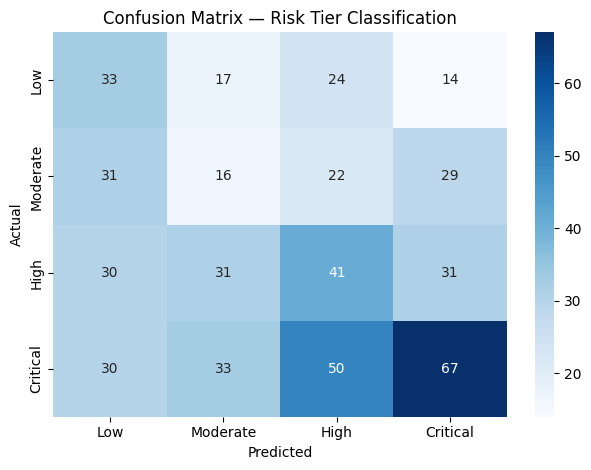

In [9]:
y_pred = rf.predict(X_test_sc)

print(classification_report(y_test, y_pred, target_names=list(TIER_LABELS.values())))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TIER_LABELS.values(),
            yticklabels=TIER_LABELS.values())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Risk Tier Classification")
plt.tight_layout()
plt.show()

### Cross validation

In [10]:
cv_scores = cross_val_score(rf, 
                             scaler.fit_transform(X), y, 
                             cv=5, scoring="f1_weighted")

print(f"CV F1 (weighted):  {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV F1 (weighted):  0.301 ± 0.031


### Feature Imortance

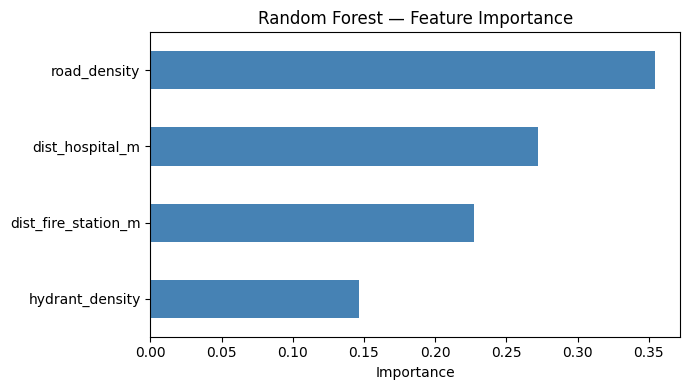

In [11]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

importances.plot(kind="barh", color="steelblue", figsize=(7, 4))
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [13]:
# explainer   = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X_test_sc)

# # Summary plot — one panel per risk tier
# shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
#                   class_names=list(TIER_LABELS.values()))

In [14]:
X_all_sc = scaler.transform(X)
tracts["predicted_tier"]      = rf.predict(X_all_sc)
tracts["predicted_tier_label"] = tracts["predicted_tier"].map(TIER_LABELS)

# Save enriched GeoJSON for visualization notebook
tracts.to_file(DATA_PROC / "tract_features_predicted.geojson", driver="GeoJSON")
print("Saved tract_features_predicted.geojson")

Saved tract_features_predicted.geojson


In [15]:
joblib.dump(rf,     MODEL_OUT / "risk_classifier.pkl")
joblib.dump(scaler, MODEL_OUT / "scaler.pkl")
print("Saved risk_classifier.pkl and scaler.pkl")

Saved risk_classifier.pkl and scaler.pkl
